# 1. Data Exploration & Preprocessing

### Import Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


### Dataset Path

In [2]:
dataset_path = "dataset"
img_size = 224
batch_size = 32

### Data Exploration

In [3]:
parasitized_path = os.path.join(dataset_path, "Parasitized")
uninfected_path = os.path.join(dataset_path, "Uninfected")

print("Parasitized Images:", len(os.listdir(parasitized_path)))
print("Uninfected Images:", len(os.listdir(uninfected_path)))

Parasitized Images: 13780
Uninfected Images: 13780


### Visualize Sample Images

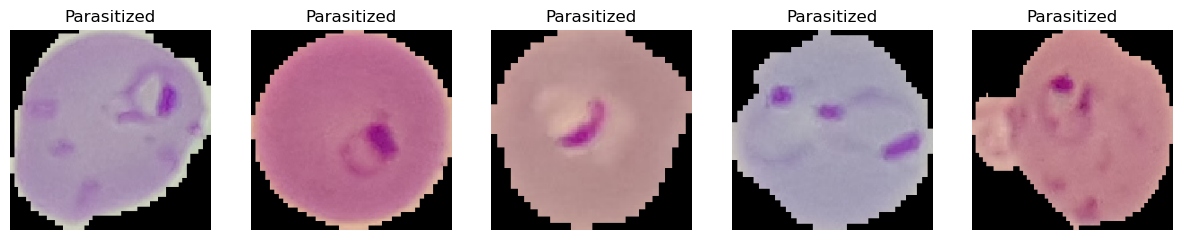

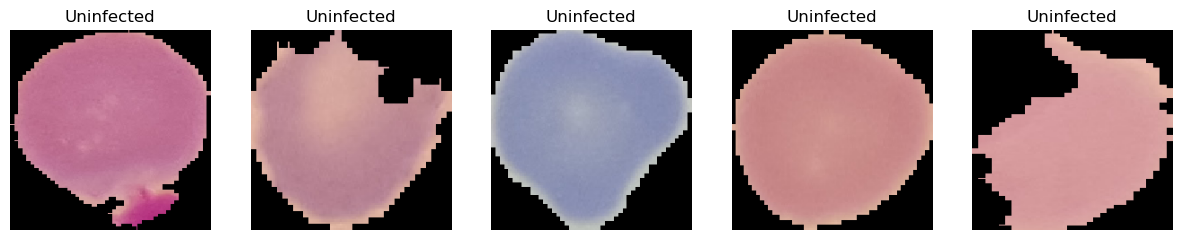

In [4]:
import random
from tensorflow.keras.preprocessing import image

def show_samples(folder, label):
    images = random.sample(os.listdir(folder), 5)
    plt.figure(figsize=(15,5))
    for i, img_name in enumerate(images):
        img_path = os.path.join(folder, img_name)
        img = image.load_img(img_path, target_size=(img_size, img_size))
        plt.subplot(1,5,i+1)
        plt.imshow(img)
        plt.title(label)
        plt.axis("off")
    plt.show()

show_samples(parasitized_path, "Parasitized")
show_samples(uninfected_path, "Uninfected")

### Train-Validation Split

In [5]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

Found 22048 images belonging to 2 classes.
Found 5510 images belonging to 2 classes.


# 2. Model Building (MobileNetV2 Transfer Learning)

### Load Pretrained Model

In [6]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(img_size, img_size, 3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


### Freeze Base Model

In [7]:
for layer in base_model.layers:
    layer.trainable = False

### Add Custom Layers

In [8]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

### Compile Model

In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Callbacks

In [12]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    "best_malaria_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

# 3. Model Training

In [13]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - accuracy: 0.7741 - loss: 0.4572

689/689 ━━━━━━━━━━━━━━━━━━━━ 532s 767ms/step - accuracy: 0.8513 - loss: 0.3354 - val_accuracy: 0.9087 - val_loss: 0.2326 - learning_rate: 1.0000e-04
Epoch 2/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.9088 - loss: 0.2343

689/689 ━━━━━━━━━━━━━━━━━━━━ 402s 583ms/step - accuracy: 0.9124 - loss: 0.2267 - val_accuracy: 0.9201 - val_loss: 0.2186 - learning_rate: 1.0000e-04
Epoch 3/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.9203 - loss: 0.2101

689/689 ━━━━━━━━━━━━━━━━━━━━ 380s 552ms/step - accuracy: 0.9197 - loss: 0.2113 - val_accuracy: 0.9223 - val_loss: 0.2113 - learning_rate: 1.0000e-04
Epoch 4/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 380s 552ms/step - accuracy: 0.9230 - loss: 0.2091 - val_accuracy: 0.9154 - val_loss: 0.2243 - learning_rate: 1.0000e-04
Epoch 5/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 379s 550ms/step - accuracy: 0.9262 - loss: 0.2008 - val_accuracy: 0.9129 - val_loss: 0.2293 - learning_rate: 1.0000e-04
Epoch 6/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 381s 553ms/step - accuracy: 0.9267 - loss: 0.1986 - val_accuracy: 0.9162 - val_loss: 0.2190 - learning_rate: 1.0000e-04
Epoch 7/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 380s 551ms/step - accuracy: 0.9281 - loss: 0.1935 - val_accuracy: 0.9196 - val_loss: 0.2129 - learning_rate: 2.0000e-05
Epoch 8/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 381s 553ms/step - accuracy: 0.9301 - loss: 0.1928 - val_accuracy: 0.9221 - val_loss: 0.2094 - learning_rate: 2.0000e-05
Epoch 9/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 379s 550ms/

689/689 ━━━━━━━━━━━━━━━━━━━━ 381s 553ms/step - accuracy: 0.9296 - loss: 0.1901 - val_accuracy: 0.9238 - val_loss: 0.2075 - learning_rate: 2.0000e-05
Epoch 11/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 382s 554ms/step - accuracy: 0.9331 - loss: 0.1902 - val_accuracy: 0.9236 - val_loss: 0.2076 - learning_rate: 2.0000e-05
Epoch 12/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.9283 - loss: 0.2007

689/689 ━━━━━━━━━━━━━━━━━━━━ 379s 550ms/step - accuracy: 0.9300 - loss: 0.1915 - val_accuracy: 0.9254 - val_loss: 0.2056 - learning_rate: 2.0000e-05
Epoch 13/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 380s 552ms/step - accuracy: 0.9315 - loss: 0.1883 - val_accuracy: 0.9238 - val_loss: 0.2053 - learning_rate: 2.0000e-05
Epoch 14/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 381s 553ms/step - accuracy: 0.9310 - loss: 0.1899 - val_accuracy: 0.9218 - val_loss: 0.2109 - learning_rate: 2.0000e-05
Epoch 15/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.9314 - loss: 0.1833

689/689 ━━━━━━━━━━━━━━━━━━━━ 380s 551ms/step - accuracy: 0.9307 - loss: 0.1884 - val_accuracy: 0.9258 - val_loss: 0.2051 - learning_rate: 2.0000e-05
Epoch 16/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 381s 553ms/step - accuracy: 0.9312 - loss: 0.1846 - val_accuracy: 0.9250 - val_loss: 0.2056 - learning_rate: 2.0000e-05
Epoch 17/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 381s 552ms/step - accuracy: 0.9324 - loss: 0.1873 - val_accuracy: 0.9223 - val_loss: 0.2087 - learning_rate: 2.0000e-05
Epoch 18/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.9337 - loss: 0.1813

689/689 ━━━━━━━━━━━━━━━━━━━━ 382s 554ms/step - accuracy: 0.9316 - loss: 0.1874 - val_accuracy: 0.9261 - val_loss: 0.2035 - learning_rate: 2.0000e-05
Epoch 19/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.9306 - loss: 0.1917

689/689 ━━━━━━━━━━━━━━━━━━━━ 380s 552ms/step - accuracy: 0.9307 - loss: 0.1884 - val_accuracy: 0.9289 - val_loss: 0.2032 - learning_rate: 2.0000e-05
Epoch 20/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 379s 551ms/step - accuracy: 0.9312 - loss: 0.1887 - val_accuracy: 0.9276 - val_loss: 0.2042 - learning_rate: 2.0000e-05


# 4. Model Evaluation

### Evaluate Model

In [14]:
val_loss, val_acc = model.evaluate(val_generator)
print("Validation Accuracy:", val_acc)
print("Validation Loss:", val_loss)

173/173 ━━━━━━━━━━━━━━━━━━━━ 77s 443ms/step - accuracy: 0.9289 - loss: 0.2032
Validation Accuracy: 0.928856611251831
Validation Loss: 0.20323395729064941


### Plot Training Graphs

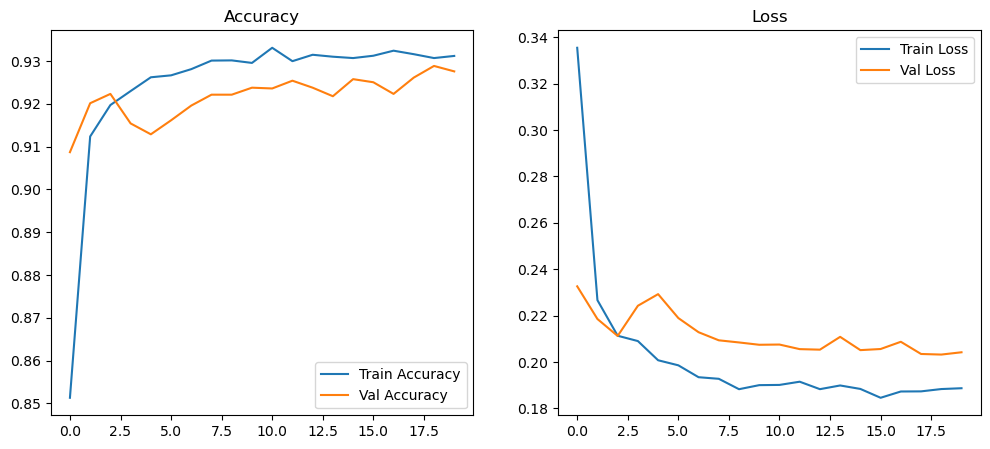

In [15]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.show()

### Confusion Matrix

173/173 ━━━━━━━━━━━━━━━━━━━━ 78s 443ms/step


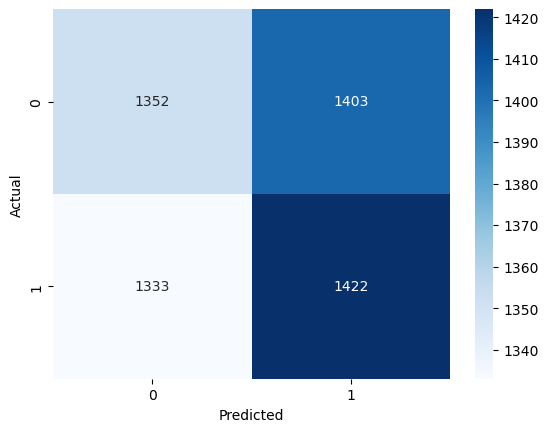

              precision    recall  f1-score   support

           0       0.50      0.49      0.50      2755
           1       0.50      0.52      0.51      2755

    accuracy                           0.50      5510
   macro avg       0.50      0.50      0.50      5510
weighted avg       0.50      0.50      0.50      5510



In [16]:
val_generator.reset()
predictions = model.predict(val_generator)
pred_labels = (predictions > 0.5).astype(int)

cm = confusion_matrix(val_generator.classes, pred_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(val_generator.classes, pred_labels))

### Save Final Model

In [17]:
model.save("malaria_final_model.h5")

# 5. Flask Web Application

### Project Structure